In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import sys; sys.path.append('/content/gdrive/MyDrive/Colab Notebooks/lib') # add library path

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

from queue import PriorityQueue

from variable_print import p,ps,pst
from gridworld import GridworldEnv
from temporal_difference import TDAgent
from grid_visualization import visualize_value_function, visualize_policy

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
np.random.seed(0)

## 초기화

In [ ]:
import gym
from gym import spaces
import numpy as np

class LeftRightEnv(gym.Env):
    """
    - 상태 0: 왼쪽 사각형(시작 지점)
    - 상태 1: B
    - 상태 2: A
    - 상태 3: 오른쪽 사각형(종료 지점)

    행동:
    - 0: 왼쪽(left)
    - 1: 오른쪽(right)

    보상:
    - 0에서 오른쪽으로 갈 때: N(-0.1, 1)
    - 그 외 이동: 0
    """
    def __init__(self):
        super(LeftRightEnv, self).__init__()

        # 행동 공간: left(0), right(1)
        self.action_space = spaces.Discrete(2)

        # 관측(상태) 공간: 4개 discrete 상태
        self.observation_space = spaces.Discrete(4)

        self.state = None
        self.done = False

    def reset(self):
        """에피소드 시작 시 상태를 0(왼쪽 사각형)으로 설정."""
        self.state = 0
        self.done = False
        return self.state

    def step(self, action):
        """에이전트의 행동에 따라 상태가 좌우로 바뀌도록 구현."""
        if self.done:
            # 이미 종료 상태라면 그대로 반환
            return self.state, 0.0, True, {}

        reward = 0.0

        if self.state == 0:
            if action == 1:  # 오른쪽
                self.state = 1
                reward = np.random.normal(-0.1, 1)
            else:  # 왼쪽 선택 시, 그대로 0에 머문다고 가정
                self.state = 0
                reward = 0.0

        elif self.state == 1:
            if action == 0:  # 왼쪽 -> 0
                self.state = 0
            else:            # 오른쪽 -> 2
                self.state = 2
            reward = 0.0

        elif self.state == 2:
            if action == 0:  # 왼쪽 -> 1
                self.state = 1
            else:            # 오른쪽 -> 3 (종료)
                self.state = 3
            reward = 0.0

        elif self.state == 3:
            # 이미 종료 상태
            self.done = True
            return self.state, 0.0, True, {}

        # 상태가 3(오른쪽 사각형)이 되면 에피소드 종료
        if self.state == 3 or self.state == 0:
            self.done = True

        return self.state, reward, self.done, {}

    def render(self, mode='human'):
        """
        현재 상태를 간단히 출력만 하는 예시.
        """
        state_names = {
            0: "LeftSquare(시작)",
            1: "B",
            2: "A",
            3: "RightSquare(종료)"
        }
        print(f"Current State: {state_names[self.state]}")


In [ ]:

env = LeftRightEnv()
obs = env.reset()
done = False
while not done:
    # 임의의 행동을 선택(0=왼쪽, 1=오른쪽)
    action = env.action_space.sample()
    obs, reward, done, info = env.step(action)
    env.render()
    print(f"Action: {action}, Reward: {reward}\n")

Current State: B
Action: 1, Reward: 0.8500884175255894

Current State: LeftSquare(시작)
Action: 0, Reward: 0.0



### `GridWorld` 초기화하기

`GridworldEnv`생성

In [ ]:
nx, ny = 4, 4
env = GridworldEnv([ny, nx])

### QLearner Agent 생성  
`SARSA`: TDAgent를 상속받아 구현  

**행동정책 : epsilon-greedy policy 적용**

In [ ]:
class QLearner(TDAgent):

    def __init__(self,
                 gamma: float,
                 num_states: int,
                 num_actions: int,
                 epsilon: float,
                 lr: float):
        super(QLearner, self).__init__(gamma=gamma,
                                       num_states=num_states,
                                       num_actions=num_actions,
                                       epsilon=epsilon,
                                       lr=lr,
                                       n_step=1)

    def get_action(self, state, mode='train'):
        if mode == 'train':
            prob = np.random.uniform(0.0, 1.0, 1)
            # e-greedy policy over Q
            if prob <= self.epsilon:  # random
                action = np.random.choice(range(self.num_actions))
            else:  # greedy
                action = self.q[state, :].argmax()
        else:
            action = self.q[state, :].argmax()
        return action

    def update_sample(self, state, action, reward, next_state, done):
        s, a, r, ns = state, action, reward, next_state
        # Q-Learning target
        td_target = r + self.gamma * self.q[ns, :].max() * (1 - done)
        self.q[s, a] += self.lr * (td_target - self.q[s, a])

In [ ]:
qlearning_agent = QLearner(gamma=1.0,        # 감가율
                           lr=1e-1,          # learning rate
                           num_states=env.nS,
                           num_actions=env.nA,
                           epsilon=0.5)      # epsilon-greedy 적용

## Q-learning update method
**평가정책: greedy policy 적용**

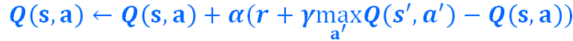

## Q-Learning 시행

In [ ]:
%%time
qlearning_agent.reset_values() # v, q <- 0

num_eps = 1000
report_every = 200
qlearning_qs = []
iter_idx = []

path_length = 0
for i in range(num_eps):  # 시행할 episode
    env.reset()           # s <- random state
    while True:           # Terminal 상태까지 반복
        state = env.s                                       # s : random
        action = qlearning_agent.get_action(state)          # a <- pi(s,a)
        next_state, reward, done, info = env.step(action)   # s' <- step(a)
        qlearning_agent.update_sample(state=state,          # s
                                      action=action,        # a
                                      reward=reward,        # r
                                      next_state=next_state,# s'
                                      done=done)
        path_length += 1 # episode 길이
        if done: break
    if i % report_every == 0:
        print(f">>Mean Length : {path_length/report_every}")# sum(epi길이)/report_every
        qlearning_qs.append(qlearning_agent.q.copy())       #시각화를 위해 q(s,a)보관
        iter_idx.append(i)
        path_length = 0

>>Mean Length : 0.11
>>Mean Length : 6.43
>>Mean Length : 3.75
>>Mean Length : 3.84
>>Mean Length : 3.845
CPU times: user 224 ms, sys: 1.69 ms, total: 226 ms
Wall time: 223 ms


## 결과 시각화

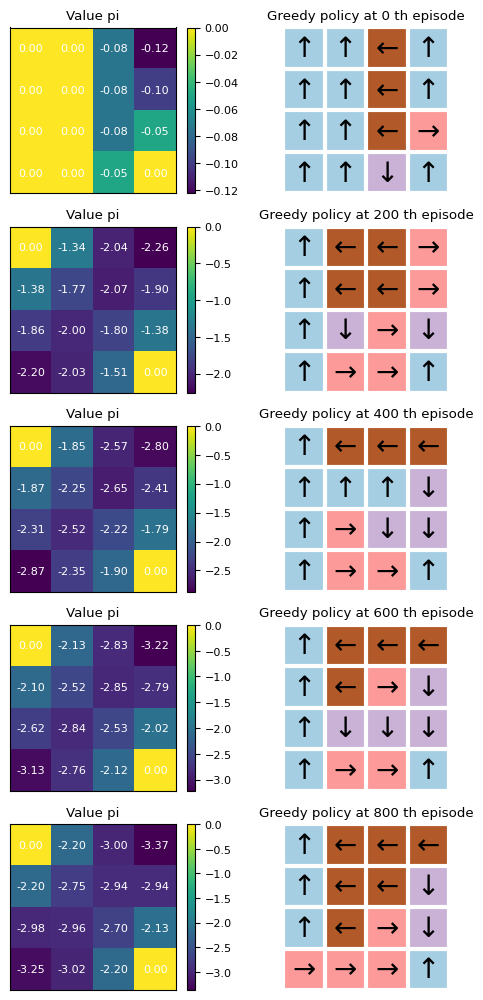

In [ ]:
num_plots = len(qlearning_qs)
fig, ax = plt.subplots(num_plots,2, figsize=(6, num_plots*2.5))
for i, (q, viz_i) in enumerate(zip(qlearning_qs, iter_idx)):
    visualize_value_function(ax[i][0], np.sum(q,axis=1)/4, nx, ny) #V(s)=sum(Q(s,a))/4
    _ = ax[i][0].set_title("Value pi")
    visualize_policy(ax[i][1], q, env.shape[0], env.shape[1])
    _ = ax[i][1].set_title("Greedy policy at {} th episode".format(viz_i))

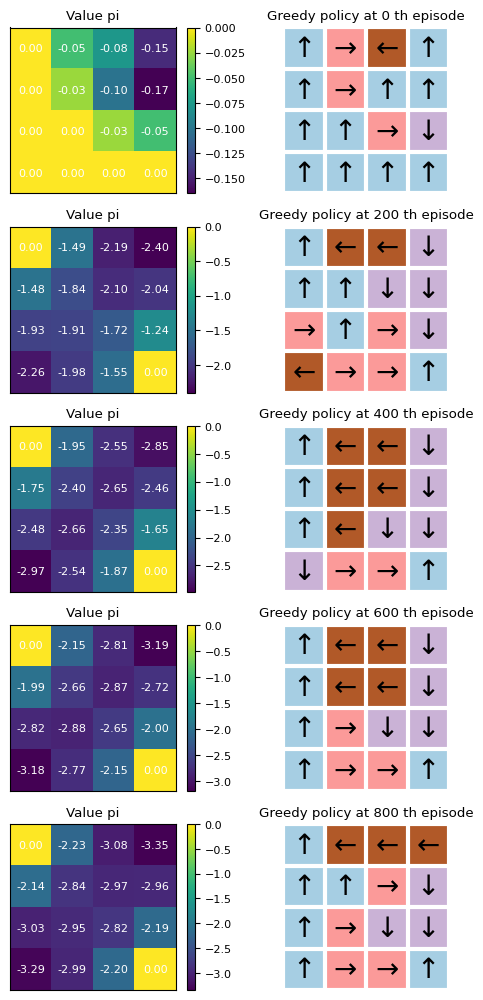